# Day 7：Capstone：提交一个可复现的闭环实验 artifact

最后一天把所有层合起来：候选配方、trajectory JSONL、evaluation、verification、
leaderboard 思维和机制解释。目标是产出一个小型但完整的科研 artifact。


In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(7)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day07


In [2]:
tu.display_learning_goal(
    7,
    "完整闭环 artifact",
    [
        "运行一组候选实验并选择当前 best condition。",
        "生成标准 trajectory JSONL。",
        "评测并重放验证 trajectory。",
        "写出结构化机制解释和 failure analysis。",
    ],
)


In [3]:
tu.display_api_card()


In [4]:
tu.display_student_checkpoint(
    7,
    [
        'one trajectory table or JSONL artifact',
        'one figure generated from your own run',
        'one chemical hypothesis',
        'one proposed next experiment',
        'one note on how GPT or another assistant was used',
    ],
)


,candidate,temperature_C,time_h,catalyst,solvent,yield,degradation,risk,score
0,C1,70.0,0.50,cat_b,ethanol,0.6210,0.0970,0.0833,0.5006
1,C2,95.0,0.40,cat_b,acetonitrile,0.5362,0.2413,0.1270,0.4123
2,C3,120.0,0.25,cat_a,acetonitrile,0.4694,0.3416,0.1781,0.3627
3,C4,85.0,0.80,cat_d,ethanol,0.3069,0.4577,0.1150,0.2379


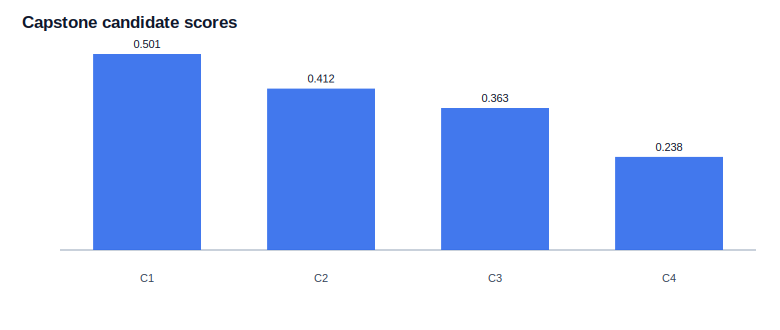

In [5]:
candidate_recipes = [
    {
        "temperature": 70.0,
        "time": 0.50,
        "initial_concentration": 0.35,
        "stirring_speed": 650.0,
        "catalyst": 1,
        "solvent": 1,
    },
    {
        "temperature": 95.0,
        "time": 0.40,
        "initial_concentration": 0.45,
        "stirring_speed": 760.0,
        "catalyst": 1,
        "solvent": 2,
    },
    {
        "temperature": 120.0,
        "time": 0.25,
        "initial_concentration": 0.30,
        "stirring_speed": 800.0,
        "catalyst": 0,
        "solvent": 2,
    },
    {
        "temperature": 85.0,
        "time": 0.80,
        "initial_concentration": 0.55,
        "stirring_speed": 700.0,
        "catalyst": 3,
        "solvent": 1,
    },
]

capstone_seed = 77
capstone_rows = []
for index, recipe in enumerate(candidate_recipes):
    result = tu.run_recipe(recipe, split='public-test', seed=capstone_seed)
    result["candidate"] = f"C{index + 1}"
    capstone_rows.append(result)
capstone_df = pd.DataFrame(capstone_rows)
display(
    capstone_df[
        [
            "candidate",
            "temperature_C",
            "time_h",
            "catalyst",
            "solvent",
            "yield",
            "degradation",
            "risk",
            "score",
        ]
    ]
)
display(
    tu.bar_svg(
        capstone_df["candidate"].tolist(),
        capstone_df["score"].astype(float).tolist(),
        title="Capstone candidate scores",
        color="#2563eb",
    )
)


In [6]:
best_index = int(capstone_df['score'].to_numpy().argmax())
best_row = capstone_df.iloc[best_index]
best_recipe = candidate_recipes[best_index]
tu.show_json_panel(
    'Best condition from candidate set',
    {
        'candidate': best_row['candidate'],
        'temperature_C': float(best_row['temperature_C']),
        'time_h': float(best_row['time_h']),
        'catalyst': best_row['catalyst'],
        'solvent': best_row['solvent'],
        'score': float(best_row['score']),
        'risk': float(best_row['risk']),
    },
)


In [7]:
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.verify import verify_records

trajectory_path = OUTPUT_DIR / 'best_candidate_capstone.jsonl'
records = tu.write_recipe_trajectory(
    best_recipe,
    trajectory_path,
    split='public-test',
    seed=capstone_seed,
    objective='balanced',
    agent_name='capstone_best_candidate_replay',
)
evaluation = evaluate_records(records).to_dict()
verification = verify_records(records).to_dict()
tu.show_json_panel('Evaluation', evaluation)
tu.show_json_panel('Replay verification', verification)


,step,operation,instrument,reward,leaderboard_score,yield,risk,observed_keys
0,1,add_solvent,None,0.0000,NaN,NaN,0.0597,"cost, safety_risk, score"
1,2,add_reagent,None,0.0000,NaN,NaN,0.0777,"cost, safety_risk, score"
2,3,add_catalyst,None,0.0000,NaN,NaN,0.0777,"cost, safety_risk, score"
3,4,heat,None,0.0000,NaN,NaN,0.0833,"cost, safety_risk, score"
4,5,terminate,None,0.0000,NaN,NaN,0.0833,"cost, safety_risk, score"
5,6,measure,final_assay,0.5006,0.5006,0.621,0.0833,"yield, selectivity, conversion, byproduct_sign..."


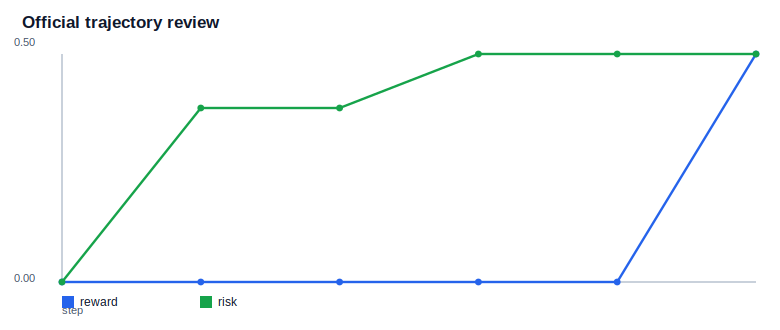

In [8]:
trajectory_df = pd.DataFrame(
    [
        {
            'step': record['step'],
            'operation': record['operation_type'],
            'instrument': record['instrument'],
            'reward': record['reward'],
            'leaderboard_score': record['leaderboard_score'],
            'yield': record['observation']['yield'],
            'risk': record['observation']['safety_risk'],
            'observed_keys': ', '.join(record['observed_keys']),
        }
        for record in records
    ]
)
display(trajectory_df)
display(
    tu.line_svg(
        trajectory_df,
        x='step',
        ys=['reward', 'risk'],
        title='Official trajectory review',
    )
)
assert (trajectory_df['instrument'] == 'final_assay').sum() == 1
assert trajectory_df['leaderboard_score'].notna().sum() == 1


In [9]:
explanation = {
    'selected_candidate': str(best_row['candidate']),
    'hypothesis': (
        'Moderate temperature and moderate time should improve yield before '
        'degradation dominates.'
    ),
    'learned_mechanism': (
        'The scans suggest a yield/degradation trade-off and meaningful '
        'catalyst-solvent interactions.'
    ),
    'failure_analysis': (
        'Single-seed candidate testing is not enough for a claim; private '
        'world generalization must be evaluated.'
    ),
    'next_experiment_rationale': (
        'Run a small local design around the selected candidate while adding '
        'risk-aware constraints and at least one cheap mid-run observation.'
    ),
}
tu.show_json_panel('Structured explanation', explanation)


## 最终交付清单

一个合格的 ChemWorld-Bench 小型提交至少应包含：

- 你的策略说明；
- trajectory JSONL；
- evaluation result；
- replay verification result；
- 机制解释、局限性和下一轮实验理由。

这就是从“会写代码”走向“会在未知化工世界中做闭环科学决策”的最小闭环。
